In [1]:
!wget https://s3.amazonaws.com/keras-datasets/jena_climate_2009_2016.csv.zip
!unzip jena_climate_2009_2016.csv.zip

--2026-03-17 20:54:42--  https://s3.amazonaws.com/keras-datasets/jena_climate_2009_2016.csv.zip
Resolving s3.amazonaws.com (s3.amazonaws.com)... 52.217.73.86, 16.182.35.176, 16.15.207.251, ...
Connecting to s3.amazonaws.com (s3.amazonaws.com)|52.217.73.86|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 13565642 (13M) [application/zip]
Saving to: ‘jena_climate_2009_2016.csv.zip’

jena_climate_2009_2 100%[===================>]  12.94M  34.4MB/s    in 0.4s    

2026-03-17 20:54:43 (34.4 MB/s) - ‘jena_climate_2009_2016.csv.zip’ saved [13565642/13565642]

Archive:  jena_climate_2009_2016.csv.zip
  inflating: jena_climate_2009_2016.csv  
  inflating: __MACOSX/._jena_climate_2009_2016.csv  


In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
from torch.utils.tensorboard import SummaryWriter

In [3]:
# --- Load data ---
fname = "jena_climate_2009_2016.csv"
with open(fname) as f:
    data = f.read()
lines = data.split("\n")
header = lines[0].split(",")
lines = lines[1:]

temperature = np.zeros((len(lines),))
raw_data = np.zeros((len(lines), len(header) - 1))
for i, line in enumerate(lines):
    values = [float(x) for x in line.split(",")[1:]]
    temperature[i] = values[1]
    raw_data[i, :] = values[:]

# --- Plots (before normalization, matching Keras notebook) ---
fig, axes = plt.subplots(2, 1, figsize=(12, 6))

axes[0].plot(range(len(temperature)), temperature)
axes[0].set_title("Full temperature record")
axes[0].set_xlabel("Timestep (every 10 min)")
axes[0].set_ylabel("Temperature (°C)")

axes[1].plot(range(1440), temperature[:1440])
axes[1].set_title("First 10 days (1440 timesteps)")
axes[1].set_xlabel("Timestep (every 10 min)")
axes[1].set_ylabel("Temperature (°C)")

plt.tight_layout()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'jena_climate_2009_2016.csv'

In [ ]:
# --- Split sizes ---
num_train_samples = int(0.5 * len(raw_data))
num_val_samples   = int(0.25 * len(raw_data))
num_test_samples  = len(raw_data) - num_train_samples - num_val_samples
print("num_train_samples:", num_train_samples)
print("num_val_samples:", num_val_samples)
print("num_test_samples:", num_test_samples)

# --- Normalize ---
scaler = StandardScaler()
scaler.fit(raw_data[:num_train_samples])
raw_data = scaler.transform(raw_data)

temp_mean = scaler.mean_[1]
temp_std  = scaler.scale_[1]
temperature = (temperature - temp_mean) / temp_std

NameError: name 'raw_data' is not defined

In [4]:
class TimeseriesDataset(Dataset):
    def __init__(self, data, targets, sequence_length):
        self.data = data
        self.targets = targets
        self.sequence_length = sequence_length

    def __len__(self):
        return len(self.targets) - self.sequence_length + 1

    def __getitem__(self, idx):
        x = self.data[idx : idx + self.sequence_length]
        y = self.targets[idx + self.sequence_length - 1]
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

In [5]:
int_sequence = np.arange(10)

dummy_dataset = TimeseriesDataset(
    data=int_sequence[:-3],       # source: [0 1 2 3 4 5 6]
    targets=int_sequence[3:],     # targets: [3 4 5 6 7 8 9]
    sequence_length=3,
)

dummy_loader = DataLoader(dummy_dataset, batch_size=2, shuffle=False)

for inputs, targets in dummy_loader:
    for i in range(inputs.shape[0]):
        print([int(x) for x in inputs[i]], int(targets[i]))

[0, 1, 2] 5
[1, 2, 3] 6
[2, 3, 4] 7
[3, 4, 5] 8
[4, 5, 6] 9


In [6]:
sampling_rate   = 6
sequence_length = 120
delay           = sampling_rate * (sequence_length + 24 - 1)
batch_size      = 256

class TimeseriesDataset(Dataset):
    def __init__(self, data, targets, sequence_length, sampling_rate, 
                 start_index, end_index, shuffle=False):
        self.data            = data
        self.targets         = targets
        self.sequence_length = sequence_length
        self.sampling_rate   = sampling_rate
        self.shuffle         = shuffle

        # Valid starting indices: each sequence of length sequence_length
        # sampled every sampling_rate steps needs:
        # (sequence_length - 1) * sampling_rate + 1 rows ahead
        self.indices = np.arange(start_index, end_index)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        start = self.indices[idx]
        # Sample every `sampling_rate` steps for `sequence_length` steps
        steps = np.arange(start, start + self.sequence_length * self.sampling_rate, 
                          self.sampling_rate)
        x = self.data[steps]
        # Target is `delay` steps ahead of the sequence start
        y = self.targets[start + delay]
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)


train_dataset = TimeseriesDataset(
    data=raw_data, targets=temperature,
    sequence_length=sequence_length, sampling_rate=sampling_rate,
    start_index=0, end_index=num_train_samples,
    shuffle=True,
)

val_dataset = TimeseriesDataset(
    data=raw_data, targets=temperature,
    sequence_length=sequence_length, sampling_rate=sampling_rate,
    start_index=num_train_samples, end_index=num_train_samples + num_val_samples,
    shuffle=False,
)

test_dataset = TimeseriesDataset(
    data=raw_data, targets=temperature,
    sequence_length=sequence_length, sampling_rate=sampling_rate,
    start_index=num_train_samples + num_val_samples, end_index=len(raw_data) - delay,
    shuffle=False,
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

# Quick sanity check
for inputs, targets in train_loader:
    print("Input shape:", inputs.shape)   # (batch_size, sequence_length, num_features)
    print("Target shape:", targets.shape) # (batch_size,)
    break

Input shape: torch.Size([256, 120, 14])
Target shape: torch.Size([256])


In [14]:
def evaluate_naive_method(loader):
    total_abs_err = 0.0
    samples_seen  = 0

    with torch.no_grad():
        for samples, targets in loader:
            preds = samples[:, -1, 1] * temp_std + temp_mean   # un-normalize to °C
            targets_celsius = targets * temp_std + temp_mean    # un-normalize targets too
            total_abs_err += torch.sum(torch.abs(preds - targets_celsius)).item()
            samples_seen  += samples.shape[0]

    return total_abs_err / samples_seen

print(f"Validation MAE: {evaluate_naive_method(val_loader):.2f}")
print(f"Test MAE:       {evaluate_naive_method(test_loader):.2f}")

Validation MAE: 2.44
Test MAE:       2.62


In [8]:
# --- Model ---
class DenseModel(nn.Module):
    def __init__(self, sequence_length, num_features):
        super().__init__()
        self.network = nn.Sequential(
            nn.Flatten(),
            nn.Linear(sequence_length * num_features, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
        )

    def forward(self, x):
        return self.network(x).squeeze(-1)  # (batch,)


# --- Training setup ---
device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model     = DenseModel(sequence_length, raw_data.shape[-1]).to(device)
optimizer = torch.optim.Adam(model.parameters())
criterion = torch.nn.MSELoss()
writer    = SummaryWriter(log_dir="runs/jena_dense")

# --- Checkpoint: track best val MAE ---
best_val_mae  = float("inf")
best_ckpt_path = "jena_dense_best.pt"

In [12]:
def run_epoch(model, loader, criterion, optimizer=None):
    training = optimizer is not None
    model.train() if training else model.eval()
    total_loss = 0.0
    total_mae  = 0.0
    n          = 0

    with torch.set_grad_enabled(training):
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            preds = model(inputs)
            loss  = criterion(preds, targets)

            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * inputs.size(0)
            total_mae  += torch.sum(torch.abs(preds - targets)).item()
            n          += inputs.size(0)

    mae_normalized = total_mae / n
    mae_celsius    = mae_normalized * temp_std   # un-normalize: just multiply by std

    return total_loss / n, mae_normalized, mae_celsius

In [19]:
# --- Training loop ---
epochs = 20
for epoch in range(1, epochs + 1):
    train_loss, train_mae, train_mae_c = run_epoch(model, train_loader, criterion, optimizer)
    val_loss,   val_mae,   val_mae_c   = run_epoch(model, val_loader,   criterion)

    writer.add_scalars("Loss",         {"train": train_loss,  "val": val_loss},  epoch)
    writer.add_scalars("MAE_norm",     {"train": train_mae,   "val": val_mae},   epoch)
    writer.add_scalars("MAE_celsius",  {"train": train_mae_c, "val": val_mae_c}, epoch)

    print(f"Epoch {epoch:02d} — "
      f"train loss: {train_loss:.4f}, train MAE: {train_mae_c:.2f}°C | "
      f"val loss: {val_loss:.4f}, val MAE: {val_mae_c:.2f}°C")


    if val_mae < best_val_mae:
        best_val_mae = val_mae
        torch.save(model.state_dict(), best_ckpt_path)
        print(f"  ✓ Best model saved (val MAE: {val_mae:.2f})")

writer.close()

Epoch 01 — train loss: 0.1567, train MAE: 2.67°C | val loss: 0.1184, val MAE: 2.34°C
  ✓ Best model saved (val MAE: 0.27)


KeyboardInterrupt: 

In [15]:
# --- Model ---
class LSTMModel(nn.Module):
    def __init__(self, num_features, hidden_size=16):
        super().__init__()
        self.lstm   = nn.LSTM(input_size=num_features, hidden_size=hidden_size, batch_first=True)
        self.linear = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # out: (batch, seq_len, hidden_size)
        # we only need the last timestep → out[:, -1, :]
        out, _ = self.lstm(x)
        return self.linear(out[:, -1, :]).squeeze(-1)  # (batch,)

In [20]:
# --- Training setup ---
model     = LSTMModel(num_features=raw_data.shape[-1]).to(device)
optimizer = torch.optim.Adam(model.parameters())
criterion = nn.MSELoss()
writer    = SummaryWriter(log_dir="runs/jena_lstm")

best_val_mae   = float("inf")
best_ckpt_path = "jena_lstm_best.pt"

In [22]:
epochs = 10
for epoch in range(1, epochs + 1):
    train_loss, train_mae, train_mae_c = run_epoch(model, train_loader, criterion, optimizer)
    val_loss,   val_mae,   val_mae_c   = run_epoch(model, val_loader,   criterion)

    writer.add_scalars("Loss", {"train": train_loss, "val": val_loss}, epoch)
    writer.add_scalars("MAE",  {"train": train_mae,  "val": val_mae},  epoch)

    print(f"Epoch {epoch:02d} — "
      f"train loss: {train_loss:.4f}, train MAE: {train_mae_c:.2f}°C | "
      f"val loss: {val_loss:.4f}, val MAE: {val_mae_c:.2f}°C")

    if val_mae < best_val_mae:
        best_val_mae = val_mae
        torch.save(model.state_dict(), best_ckpt_path)
        print(f"  ✓ Best model saved (val MAE: {val_mae:.2f})")

writer.close()

Epoch 01 — train loss: 0.1751, train MAE: 2.77°C | val loss: 0.1185, val MAE: 2.35°C
  ✓ Best model saved (val MAE: 0.27)
Epoch 02 — train loss: 0.1278, train MAE: 2.45°C | val loss: 0.1167, val MAE: 2.32°C
  ✓ Best model saved (val MAE: 0.26)
Epoch 03 — train loss: 0.1216, train MAE: 2.38°C | val loss: 0.1143, val MAE: 2.30°C
  ✓ Best model saved (val MAE: 0.26)
Epoch 04 — train loss: 0.1153, train MAE: 2.33°C | val loss: 0.1141, val MAE: 2.30°C
  ✓ Best model saved (val MAE: 0.26)
Epoch 05 — train loss: 0.1107, train MAE: 2.28°C | val loss: 0.1186, val MAE: 2.36°C
Epoch 06 — train loss: 0.1042, train MAE: 2.22°C | val loss: 0.1174, val MAE: 2.34°C
Epoch 07 — train loss: 0.0998, train MAE: 2.17°C | val loss: 0.1205, val MAE: 2.36°C
Epoch 08 — train loss: 0.0975, train MAE: 2.15°C | val loss: 0.1225, val MAE: 2.38°C
Epoch 09 — train loss: 0.0979, train MAE: 2.16°C | val loss: 0.1261, val MAE: 2.41°C
Epoch 10 — train loss: 0.0929, train MAE: 2.10°C | val loss: 0.1322, val MAE: 2.47°C


In [26]:
# --- Reload best and evaluate ---
model.load_state_dict(torch.load(best_ckpt_path, map_location=device))
test_loss,   test_mae,   test_mae_c = run_epoch(model, test_loader,   criterion)
print(f"\nTest MAE: {test_mae_c:.2f}°C")


Test MAE: 2.42°C


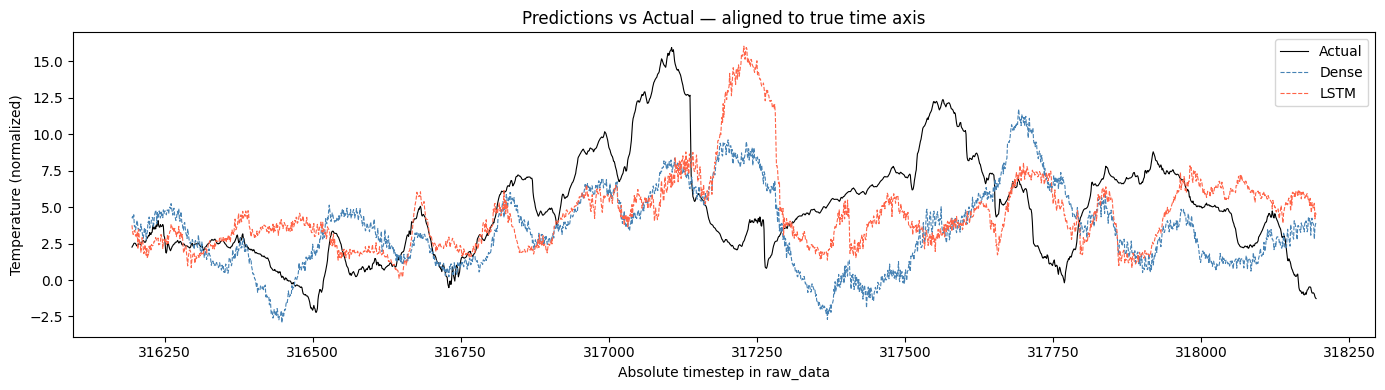

In [29]:
def get_predictions(model, dataset):
    model.eval()
    all_preds     = []
    all_targets   = []
    all_timesteps = []

    loader = DataLoader(dataset, batch_size=256, shuffle=False)
    with torch.no_grad():
        for batch_idx, (inputs, targets) in enumerate(loader):
            preds = model(inputs.to(device)).cpu().numpy()
            all_preds.append(preds * temp_std + temp_mean)
            all_targets.append(targets.numpy() * temp_std + temp_mean)

            start_idx = batch_idx * 256
            timesteps = [dataset.indices[start_idx + i] + delay
                         for i in range(len(targets))]
            all_timesteps.append(np.array(timesteps))

    return (np.concatenate(all_timesteps),
            np.concatenate(all_preds),
            np.concatenate(all_targets))


dense_model = DenseModel(sequence_length, raw_data.shape[-1]).to(device)
dense_model.load_state_dict(torch.load("jena_dense_best.pt", map_location=device))

lstm_model = LSTMModel(num_features=raw_data.shape[-1]).to(device)
lstm_model.load_state_dict(torch.load("jena_lstm_best.pt", map_location=device))

timesteps, dense_preds, targets = get_predictions(dense_model, test_dataset)
_,         lstm_preds,  _       = get_predictions(lstm_model,  test_dataset)

zoom = 2000
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(timesteps[:zoom], targets[:zoom],     label="Actual", color="black",     linewidth=0.8)
ax.plot(timesteps[:zoom], dense_preds[:zoom], label="Dense",  color="steelblue", linewidth=0.8, linestyle="--")
ax.plot(timesteps[:zoom], lstm_preds[:zoom],  label="LSTM",   color="tomato",    linewidth=0.8, linestyle="--")
ax.set_xlabel("Absolute timestep in raw_data")
ax.set_ylabel("Temperature (normalized)")
ax.set_title("Predictions vs Actual — aligned to true time axis")
ax.legend()
plt.tight_layout()
plt.show()



In [30]:
class LSTMDropoutModel(nn.Module):
    def __init__(self, num_features, hidden_size=32, dropout=0.5, recurrent_dropout=0.25):
        super().__init__()
        self.lstm    = nn.LSTM(input_size=num_features, hidden_size=hidden_size,
                               batch_first=True)
        self.recurrent_dropout = nn.Dropout(recurrent_dropout)
        self.dropout = nn.Dropout(dropout)
        self.head    = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # Approximate recurrent dropout: apply dropout on the input
        # to the LSTM (variational dropout approximation)
        x, _  = self.lstm(self.recurrent_dropout(x))
        return self.head(self.dropout(x[:, -1, :])).squeeze(-1)


# --- Setup ---
model          = LSTMDropoutModel(num_features=raw_data.shape[-1]).to(device)
optimizer      = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion      = nn.MSELoss()
writer         = SummaryWriter(log_dir="runs/jena_lstm_dropout")
best_val_mae   = float("inf")
best_ckpt_path = "jena_lstm_dropout_best.pt"

In [31]:
# --- Training loop ---
epochs = 50
for epoch in range(1, epochs + 1):
    train_loss, train_mae, train_mae_c = run_epoch(model, train_loader, criterion, optimizer)
    val_loss,   val_mae,   val_mae_c   = run_epoch(model, val_loader,   criterion)

    writer.add_scalars("Loss",        {"train": train_loss,  "val": val_loss},  epoch)
    writer.add_scalars("MAE_norm",    {"train": train_mae,   "val": val_mae},   epoch)
    writer.add_scalars("MAE_celsius", {"train": train_mae_c, "val": val_mae_c}, epoch)

    print(f"Epoch {epoch:02d} — "
          f"train loss: {train_loss:.4f}, train MAE: {train_mae_c:.2f}°C | "
          f"val loss: {val_loss:.4f}, val MAE: {val_mae_c:.2f}°C")

    if val_mae < best_val_mae:
        best_val_mae = val_mae
        torch.save(model.state_dict(), best_ckpt_path)
        print(f"  ✓ Best model saved (val MAE: {val_mae_c:.2f}°C)")

writer.close()

Epoch 01 — train loss: 0.2048, train MAE: 3.06°C | val loss: 0.1275, val MAE: 2.45°C
  ✓ Best model saved (val MAE: 2.45°C)
Epoch 02 — train loss: 0.1734, train MAE: 2.85°C | val loss: 0.1230, val MAE: 2.39°C
  ✓ Best model saved (val MAE: 2.39°C)
Epoch 03 — train loss: 0.1697, train MAE: 2.81°C | val loss: 0.1213, val MAE: 2.37°C
  ✓ Best model saved (val MAE: 2.37°C)
Epoch 04 — train loss: 0.1654, train MAE: 2.77°C | val loss: 0.1216, val MAE: 2.38°C
Epoch 05 — train loss: 0.1613, train MAE: 2.74°C | val loss: 0.1217, val MAE: 2.39°C
Epoch 06 — train loss: 0.1580, train MAE: 2.71°C | val loss: 0.1269, val MAE: 2.44°C
Epoch 07 — train loss: 0.1547, train MAE: 2.69°C | val loss: 0.1182, val MAE: 2.35°C
  ✓ Best model saved (val MAE: 2.35°C)
Epoch 08 — train loss: 0.1521, train MAE: 2.67°C | val loss: 0.1236, val MAE: 2.41°C
Epoch 09 — train loss: 0.1500, train MAE: 2.65°C | val loss: 0.1259, val MAE: 2.43°C
Epoch 10 — train loss: 0.1483, train MAE: 2.63°C | val loss: 0.1258, val MAE: 2

KeyboardInterrupt: 

In [32]:
model.load_state_dict(torch.load(best_ckpt_path, map_location=device))
_, test_mae, test_mae_c = run_epoch(model, test_loader, criterion)
print(f"\nTest MAE: {test_mae_c:.2f}°C")


Test MAE: 2.54°C


In [35]:
class StackedGRUModel(nn.Module):
    """
    Stacked GRU with dropout.
    Same recurrent_dropout caveat as the LSTM: we approximate it
    with input dropout since nn.GRU dropout only works between stacked layers.
    """
    def __init__(self, num_features, hidden_size=32, dropout=0.3, recurrent_dropout=0.25):
        super().__init__()
        self.recurrent_dropout = nn.Dropout(recurrent_dropout)

        # return_sequences=True equivalent: just pass full output to next layer
        self.gru1  = nn.GRU(input_size=num_features, hidden_size=hidden_size,
                            batch_first=True)
        self.gru2  = nn.GRU(input_size=hidden_size, hidden_size=hidden_size,
                            batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.head    = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # Approximate recurrent dropout on input
        x, _ = self.gru1(self.recurrent_dropout(x))   # full sequence output
        x, _ = self.gru2(self.recurrent_dropout(x))   # full sequence → last timestep
        return self.head(self.dropout(x[:, -1, :])).squeeze(-1)




In [ ]:
# --- Setup ---
model          = StackedGRUModel(num_features=raw_data.shape[-1]).to(device)
optimizer      = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion      = nn.MSELoss()
writer         = SummaryWriter(log_dir="runs/jena_stacked_gru")
best_val_mae   = float("inf")
best_ckpt_path = "jena_stacked_gru_best.pt"

# --- Training loop ---
epochs = 50
for epoch in range(1, epochs + 1):
    train_loss, train_mae, train_mae_c = run_epoch(model, train_loader, criterion, optimizer)
    val_loss,   val_mae,   val_mae_c   = run_epoch(model, val_loader,   criterion)

    writer.add_scalars("Loss",        {"train": train_loss,  "val": val_loss},  epoch)
    writer.add_scalars("MAE_norm",    {"train": train_mae,   "val": val_mae},   epoch)
    writer.add_scalars("MAE_celsius", {"train": train_mae_c, "val": val_mae_c}, epoch)

    print(f"Epoch {epoch:02d} — "
          f"train loss: {train_loss:.4f}, train MAE: {train_mae_c:.2f}°C | "
          f"val loss: {val_loss:.4f}, val MAE: {val_mae_c:.2f}°C")

    if val_mae < best_val_mae:
        best_val_mae = val_mae
        torch.save(model.state_dict(), best_ckpt_path)
        print(f"  ✓ Best model saved (val MAE: {val_mae_c:.2f}°C)")

writer.close()



Epoch 01 — train loss: 0.3030, train MAE: 3.66°C | val loss: 0.1352, val MAE: 2.53°C
  ✓ Best model saved (val MAE: 2.53°C)
Epoch 02 — train loss: 0.1832, train MAE: 2.94°C | val loss: 0.1273, val MAE: 2.45°C
  ✓ Best model saved (val MAE: 2.45°C)
Epoch 03 — train loss: 0.1740, train MAE: 2.87°C | val loss: 0.1236, val MAE: 2.42°C
  ✓ Best model saved (val MAE: 2.42°C)
Epoch 04 — train loss: 0.1682, train MAE: 2.82°C | val loss: 0.1233, val MAE: 2.41°C
  ✓ Best model saved (val MAE: 2.41°C)
Epoch 05 — train loss: 0.1654, train MAE: 2.79°C | val loss: 0.1209, val MAE: 2.39°C
  ✓ Best model saved (val MAE: 2.39°C)
Epoch 06 — train loss: 0.1622, train MAE: 2.76°C | val loss: 0.1198, val MAE: 2.38°C
  ✓ Best model saved (val MAE: 2.38°C)
Epoch 07 — train loss: 0.1605, train MAE: 2.74°C | val loss: 0.1186, val MAE: 2.36°C
  ✓ Best model saved (val MAE: 2.36°C)
Epoch 08 — train loss: 0.1588, train MAE: 2.73°C | val loss: 0.1187, val MAE: 2.36°C
Epoch 09 — train loss: 0.1573, train MAE: 2.72°

In [ ]:
model.load_state_dict(torch.load(best_ckpt_path, map_location=device))
_, test_mae, test_mae_c = run_epoch(model, test_loader, criterion)
print(f"\nTest MAE: {test_mae_c:.2f}°C")